In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

2026-04-14 20:01:53.202064: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 20:01:53.203736: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-14 20:01:53.225423: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-14 20:01:53.225451: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-14 20:01:53.225470: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

# 各パス指定

In [2]:
dataset = 'model/keypoint_classifier/keypoint_v2.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier_v2.hdf5'

In [3]:
# Load class labels for display
label_path = 'model/keypoint_classifier/keypoint_classifier_v2_label.csv'
with open(label_path, encoding='utf-8-sig') as f:
    CLASS_NAMES = [row[0] for row in csv.reader(f)]
print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")

Classes (5): ['null', 'pointer_move', 'left_click', 'drag_hold', 'scroll_mode']


# 分類数設定

# データ探索 (Data Exploration)

Total samples: 542, Columns: 94 (1 label + 93 features)

  [1] pointer_move   :   214 samples
  [2] left_click     :   160 samples
  [3] drag_hold      :   168 samples

✅ Balance OK (max/min ratio = 1.3x)


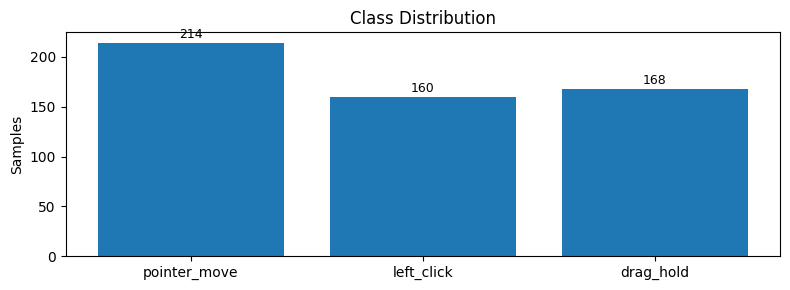

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load raw data
raw = pd.read_csv(dataset, header=None)
print(f"Total samples: {len(raw)}, Columns: {raw.shape[1]} (1 label + {raw.shape[1]-1} features)")
print()

# Class distribution
dist = raw[0].value_counts().sort_index()
for idx, count in dist.items():
    name = CLASS_NAMES[idx] if idx < len(CLASS_NAMES) else f"unknown_{idx}"
    print(f"  [{idx}] {name:15s}: {count:5d} samples")

# Warning for imbalanced classes
min_count = dist.min()
max_count = dist.max()
if max_count > 2 * min_count:
    print(f"\n⚠️  Imbalanced! max/min ratio = {max_count/min_count:.1f}x. Consider collecting more for under-represented classes.")
else:
    print(f"\n✅ Balance OK (max/min ratio = {max_count/min_count:.1f}x)")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.bar([CLASS_NAMES[i] if i < len(CLASS_NAMES) else f"?{i}" for i in dist.index], dist.values)
ax.set_ylabel("Samples")
ax.set_title("Class Distribution")
for bar, v in zip(bars, dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

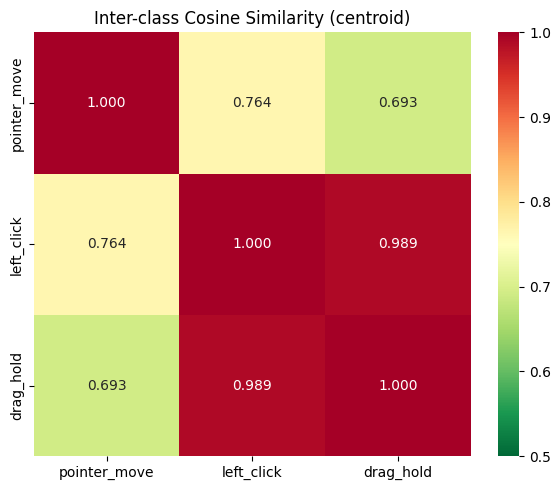


Pairs with similarity > 0.95 (potential confusion):
  ⚠️  left_click ↔ drag_hold: 0.9886


In [6]:
# Inter-class similarity check (centroid cosine distance)
# Helps detect if left_click and drag_hold (or other pairs) are too similar
from sklearn.metrics.pairwise import cosine_similarity

features = raw.iloc[:, 1:].values
labels = raw.iloc[:, 0].values

centroids = {}
for cls_id in sorted(set(labels)):
    centroids[cls_id] = features[labels == cls_id].mean(axis=0)

centroid_matrix = np.array([centroids[k] for k in sorted(centroids.keys())])
cos_sim = cosine_similarity(centroid_matrix)

# Display as heatmap
import seaborn as sns
fig, ax = plt.subplots(figsize=(6, 5))
names = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else f"?{i}" for i in sorted(centroids.keys())]
sns.heatmap(cos_sim, annot=True, fmt='.3f', xticklabels=names, yticklabels=names,
            cmap='RdYlGn_r', vmin=0.5, vmax=1.0, ax=ax)
ax.set_title("Inter-class Cosine Similarity (centroid)")
plt.tight_layout()
plt.show()

# Flag similar pairs
print("\nPairs with similarity > 0.95 (potential confusion):")
flagged = False
for i in range(len(names)):
    for j in range(i+1, len(names)):
        sim = cos_sim[i][j]
        if sim > 0.95:
            print(f"  ⚠️  {names[i]} ↔ {names[j]}: {sim:.4f}")
            flagged = True
if not flagged:
    print("  ✅ No overly similar pairs detected")

In [7]:
NUM_CLASSES = len(CLASS_NAMES)
print(f"NUM_CLASSES = {NUM_CLASSES}")

NUM_CLASSES = 5


# 学習データ読み込み

## モデルの前提と限界

This notebook trains a single-frame pose classifier based on the current 93-dim hand geometry.

Suitable use cases:
- null
- pointer_move
- left_click as a pinch state
- scroll_mode

Important limitation:
- click and drag share the same static starting pose (pinch)
- the difference is mainly temporal: how long the pinch is held and whether the cursor moves while pinched
- therefore, drag should be decided in the application layer using time and movement thresholds, not by this Dense model alone

Conclusion:
- Dense is appropriate for static hand pose recognition
- RNN/LSTM is only needed if you want the model itself to classify motion sequences end-to-end

In [ ]:
X_dataset = np.loadtxt(dataset, delimiter=",", dtype="float32", usecols=list(range(1, 94)))

In [ ]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# モデル構築

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((93, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
])

In [ ]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

In [ ]:
# モデルチェックポイントのコールバック
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# 早期打ち切り用コールバック
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [ ]:
# モデルコンパイル
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# モデル訓練

In [ ]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

In [ ]:
# モデル評価
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

In [ ]:
# 保存したモデルのロード
model = tf.keras.models.load_model(model_save_path)

In [ ]:
# 推論テスト
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

# 混同行列

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, class_names=None, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    tick_labels = [class_names[i] if class_names and i < len(class_names) else str(i) for i in labels]
    df_cmx = pd.DataFrame(cmx_data, index=tick_labels, columns=tick_labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g', square=False)
    ax.set_ylim(len(set(y_true)), 0)
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_true, y_pred, labels=labels,
                                    target_names=tick_labels))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred, CLASS_NAMES)

# Tensorflow-Lite用のモデルへ変換

In [ ]:
# 推論専用のモデルとして保存
model.save(model_save_path, include_optimizer=False)

In [ ]:
# モデルを変換(量子化)
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier_v2.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

# 推論テスト

In [ ]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [ ]:
# 入出力テンソルを取得
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [ ]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [ ]:
%%time
# 推論実施
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

In [ ]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))